In [1]:
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification

C:\Users\chauh\anaconda3\envs\dl_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_excel("Maindata.xlsx")

In [3]:
df = df[["Review_Text", "Sentiment"]]

In [4]:
df.head()

,Review_Text,Sentiment
0,Very satisfied with the performance,Positive
1,Product is okay nothing special,Neutral
2,Terrible experience overall 😤,Negative
3,Terrible experience overall,Negative
4,Not worth the price,Negative


In [5]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

model.load_state_dict(torch.load("bert_sentiment_model.pth"))

model.eval()

Loading weights: 100%|████████████████| 199/199 [00:01<00:00, 161.88it/s, Materializing param=bert.pooler.dense.weight]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initializ

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [11]:
predict_sentiment("Product was amazing")

2

In [13]:
from tqdm import tqdm

texts = df["Review_Text"].tolist()

batch_size = 64
predictions = []

for i in tqdm(range(0, len(texts), batch_size)):

    batch = texts[i:i+batch_size]

    inputs = tokenizer(
        batch,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    preds = torch.argmax(logits, dim=1)

    predictions.extend(preds.numpy())

df["predicted_sentiment"] = predictions

100%|████████████████████████████████████████████████████████████████████████████████| 188/188 [05:21<00:00,  1.71s/it]


In [16]:
df.sample(5)

,Review_Text,Sentiment,predicted_sentiment
5997,Highly recommended for everyone,Positive,2
11295,Highly recommended for everyone 👍,Positive,2
2412,Yeah actually Not bad not great,Neutral,1
10760,This product is really good and works as expected,Positive,2
5348,Highly recommended for everyone,Positive,2


In [21]:
##From the dataframe, take only rows where sentiment is positive, and extract their review text.
positive_reviews = df[df["predicted_sentiment"] == 2]["Review_Text"]
neutral_reviews = df[df["predicted_sentiment"] == 1]["Review_Text"]
negative_reviews = df[df["predicted_sentiment"] == 0]["Review_Text"]

print("Positive reviews:", len(positive_reviews))
print("Neutral reviews:", len(neutral_reviews))
print("Negative reviews:", len(negative_reviews))


Positive reviews: 3885
Neutral reviews: 4116
Negative reviews: 3999


In [22]:
positive_text = " ".join(positive_reviews)
negative_text = " ".join(negative_reviews)
neutral_text = " ".join(neutral_reviews)

In [19]:
!pip install nltk

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 1.1 MB/s eta 0:00:01
   -------------------- ------------------- 0.8/1.5 MB 1.3 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.5 MB 1.4 MB/s eta 0:00:01
   ---------------------------------- ----- 1.3/1.5 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.2 MB/s  0:00:01


In [24]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chauh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [27]:
from nltk.corpus import stopwords
from collections import Counter
import re

In [28]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return words

In [30]:
positive_words = clean_text(positive_text)
negative_words = clean_text(negative_text)

positive_common = Counter(positive_words).most_common(17)
negative_common = Counter(negative_words).most_common(17)

print("Top Positive Words:")
print(positive_common)

print("\nTop Negative Words:")
print(negative_common)

Top Positive Words:
[('satisfied', 813), ('performance', 813), ('product', 801), ('really', 801), ('good', 801), ('works', 801), ('expected', 801), ('highly', 789), ('recommended', 789), ('everyone', 789), ('absolutely', 786), ('loved', 786), ('experience', 786), ('worth', 696), ('money', 696), ('basically', 208), ('honestly', 195)]

Top Negative Words:
[('terrible', 837), ('experience', 837), ('overall', 837), ('disappointed', 816), ('product', 816), ('stopped', 803), ('working', 803), ('days', 803), ('quality', 800), ('poor', 800), ('worth', 743), ('price', 726), ('mean', 252), ('honestly', 212), ('umm', 209), ('basically', 168), ('okay', 161)]


In [31]:
!pip install wordcloud

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 5.6 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.1 MB 5.6 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 5.9 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.1 MB 6.2 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.4 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 6.9 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [kiwisolver]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ----------------------

In [32]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

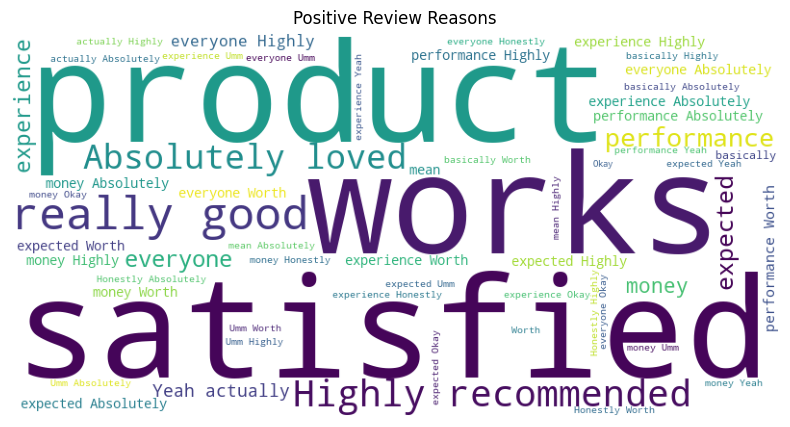

In [33]:
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Review Reasons")
plt.show()

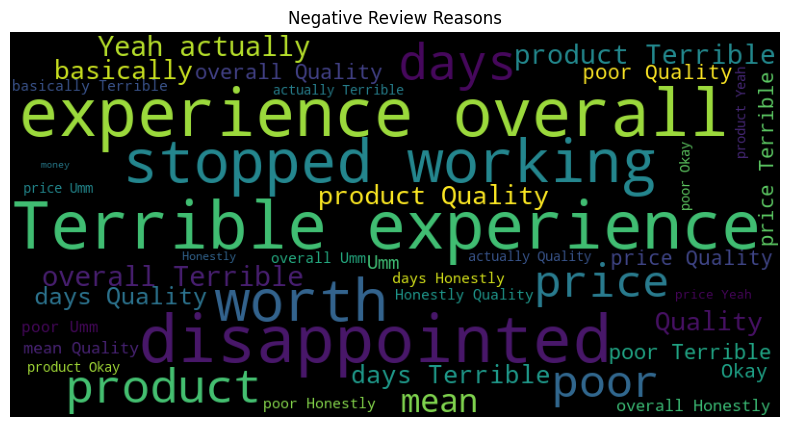

In [34]:
wordcloud = WordCloud(width=800, height=400, background_color="black").generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Review Reasons")
plt.show()

In [39]:
from sklearn.feature_extraction.text import CountVectorizer

In [47]:
def extract_reason_phrases(text_list, n=10):

    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=(2,2)  # bigrams
    )

    X = vectorizer.fit_transform(text_list)

    sum_words = X.sum(axis=0)

    words_freq = [
        (word, sum_words[0, idx])
        for word, idx in vectorizer.vocabulary_.items()
    ]

    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return words_freq[:n]

In [48]:
positive_phrases = extract_reason_phrases(positive_reviews)

print("Top Positive Reasons:")
print(positive_phrases)

Top Positive Reasons:
[('satisfied performance', np.int64(813)), ('product really', np.int64(801)), ('really good', np.int64(801)), ('good works', np.int64(801)), ('works expected', np.int64(801)), ('highly recommended', np.int64(789)), ('absolutely loved', np.int64(786)), ('loved experience', np.int64(786)), ('worth money', np.int64(696)), ('yeah actually', np.int64(175))]


In [49]:
negative_phrases = extract_reason_phrases(negative_reviews)

print("Top Negative Reasons:")
print(negative_phrases)

Top Negative Reasons:
[('terrible experience', np.int64(837)), ('experience overall', np.int64(837)), ('disappointed product', np.int64(816)), ('stopped working', np.int64(803)), ('working days', np.int64(803)), ('quality poor', np.int64(800)), ('worth price', np.int64(726)), ('yeah actually', np.int64(140)), ('mean worth', np.int64(66)), ('mean quality', np.int64(53))]


In [54]:
def explain_review(text):

    sentiment_id = predict_sentiment(text)

    sentiment_map = {
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    }

    sentiment = sentiment_map[sentiment_id]

    keywords = clean_text(text)

    phrases = extract_reason_phrases([text])

    print("Review:", text)
    print("Sentiment:", sentiment)
    print("Keyword Reasons:", keywords)
    print("Possible Reason Phrases:", [p[0] for p in phrases])

In [56]:
explain_review("The delivery was not great")

Review: The delivery was not great
Sentiment: Negative
Keyword Reasons: ['delivery', 'great']
Possible Reason Phrases: ['delivery great']
